## Roots of a function using the secant method

Kepler equation. Solve for $E$ given a value of $e \in (0, 1)$ and $M \in [0, 2 \pi]$:

$$
    E - e \, \sin(E) - M = 0
$$

We're going to use the secant method to find $E$ iteratively

First, let's guess where $E$ lies by plotting $f(E\, ; \, e, \, M)$:

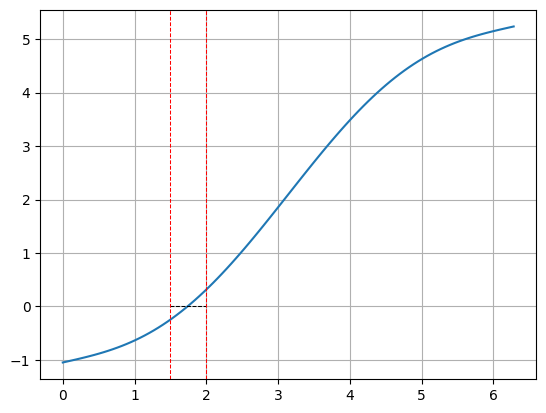

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(E, e, M):
    return E - e * np.sin(E) - M

E = np.linspace(0, 2 * np.pi, 100)
e, M = 0.7, np.pi / 3.0 # e = 0.7, M = pi / 3

# Fast plot
plt.plot(E, f(E, e, M))
plt.plot([1.5, 2.0], [0, 0], linestyle = '--', color = 'black', linewidth = 0.75)
plt.axvline(1.5, linestyle = '--', color = 'red', linewidth = 0.75)
plt.axvline(2.0, linestyle = '--', color = 'red', linewidth = 0.75)
plt.grid(True)
plt.show()

Interval found: $E \in [3 / 2, 2]$

### Secant method

The secant method is a root-finding algorithm that approximates the derivative in Newton's method using a finite difference. Instead of requiring a derivative, it uses two initial guesses to draw a secant line through their function values, then follows that line to the x-axis for the next approximation. It repeats this process iteratively until convergence, achieving superlinear (though not quadratic) convergence without needing analytical derivatives.

The secant formula is:

$$
    x_{n+1} = x_n - f(x_n) \cdot \frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}
$$

In [2]:
def secant(f, args, a, b, eps, tol, N):

    e, M = args # e and M parameters for f()

    # Initial guesses and their function values
    x0 = a
    x1 = b
    f0 = f(x0, e, M)
    f1 = f(x1, e, M)

    x_array = []
    err_array = []
    f_array = []

    j = 0 # Guard
    while j < N:

        denominator = f1 - f0
        if abs(denominator) < 1e-12:
            print(f"The denominator too small at j = {j}. Stopping.")
            break

        x_new = x1 - f1 * (x1 - x0) / denominator # Secant formula: x_new = x1 - f1 * (x1 - x0) / (f1 - f0)
        x_array.append(x_new)

        f_new = f(x_new, e, M) # Computing f_new
        f_array.append(f_new)

        if abs(f_new) < tol: # Check if f(x_new) is near zero
            print(f"While loop ended at j = {j}: f(x) is below the threshold\n")
            break

        x_old = x1 # Keep the old x1 for error computation after the update

        # Update guesses for the next iteration
        x0, f0 = x1, f1
        x1, f1 = x_new, f_new

        j += 1  # increment iteration counter

        err = abs(x_new - x_old) # Estimate the absolute error
        err_array.append(err)

        if err < eps:
            print(f"While loop ended at j = {j}: absolute error of x is below the threshold\n")
            break

        if j == N:
            print(f"While loop ended at j = {N}: maximum number of iterations reached")

    return np.array(x_array), np.array(err_array), np.array(f_array)

In [3]:
a, b = 1.5, 2.0 # a = 1.5, b = 2.0 from the plot above
N = 20 # Maximum number of iterations
eps = 1e-06 # Maximum error of e desired
tol = 1e-09 # Maximum tolerance for f(x) desired

E_array, err_array, f_array = secant(f, (e, M), a, b, eps, tol, N)
E_array, err_array, f_array

While loop ended at j = 4: f(x) is below the threshold



(array([1.71846832, 1.7360831 , 1.73750255, 1.73749419, 1.73749419]),
 array([2.81531680e-01, 1.76147792e-02, 1.41945513e-03, 8.36782054e-06]),
 array([-2.11106350e-02, -1.57430021e-03,  9.33568150e-06, -4.07573642e-09,
        -1.04360964e-14]))

In [4]:
E_array[-1], err_array[-1], f_array[-1] # Final values

(np.float64(1.7374941901659016),
 np.float64(8.367820541588245e-06),
 np.float64(-1.0436096431476471e-14))

In [5]:
# Plotting results function
def plot(E_array, err_array, f_array):
    fig, axes = plt.subplots(3, 1, figsize = (7, 7), sharex = True)

    axes[0].plot(E_array, 'bo-', label = 'E')
    axes[0].set_ylabel('E')
    axes[0].set_title('E convergence')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(f_array, 'ro-', label = 'f(E)')
    axes[1].axhline(0, color = 'k', linestyle = '--', linewidth = 0.75)
    axes[1].set_ylabel('f(E)')
    axes[1].set_title('Function values at E')
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(err_array, 'go-', label = 'Absolute error')
    axes[2].set_xlabel('Iterations')
    axes[2].set_ylabel('Error')
    axes[2].set_title('Error convergence')
    axes[2].grid(True)
    axes[2].legend()

    fig.suptitle('Method results', fontsize = 14)

    plt.tight_layout(rect = [0, 0, 1, 0.98])
    plt.show()

    return None

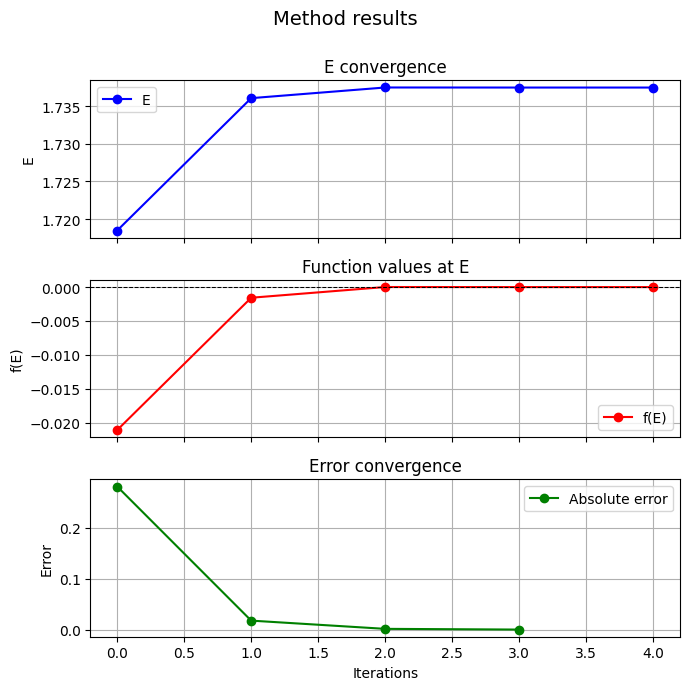

In [6]:
plot(E_array, err_array, f_array) # Plotting

We got:

$$
    E = 1.737494 \pm 0.000008 \, (5 \times 10^{-4} \, \%)
$$

Let's compare this result with that obtained by the bisection method

In [7]:
def bisection(f, args, a, b, eps, tol, N):

    e, M = args

    j = 0 # While loop guard
    while (j < N):

        m = (a + b) / 2.0 # Compute the midpoint of [a, b]
        fm = f(m, e, M) # Compute the value of f at the midpoint m

        if abs(fm) < tol: # f(m) is near zero. End loop
            print(f"While loop ended at j = {j}: fm is below the threshold\n")
            break

        if np.sign(fm) * np.sign(f(a, e, M)) == - 1: # x lies within [a, m]
            b = m
        else: # x lies in [m, b]
            a = m

        j += 1 # Update j

        err = abs((b - a)) / 2.0 # Update the absolute error

        if err < eps: # absolute error is below epsilon. End loop
            print(f"While loop ended at j = {j}: absolute error of x is below the threshold\n")
            break

        if j == N:
            print(f"While loop ended at j = {N}: maximum number of iterations reached")

    return m, err, fm # m values, absolute errors and f(m) values

In [8]:
bisection(f, (e, M), a, b, eps, tol, N) # Same parameters

While loop ended at j = 18: absolute error of x is below the threshold



(1.7374935150146484, 9.5367431640625e-07, np.float64(-7.535691330939898e-07))

By the bisection method, we got:

$$
    E = 1.737494 \pm 0.000001 \, (6 \times 10^{-5} \, \%)
$$

The bisection method yields a smaller error but is slower than the secant algorithm